# Variant Analysis of the Hebrew Manuscripts of Ben Sira

In [14]:
import os
import copy
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram


In [15]:
words_count = {}
variations = {}
ratio_var = {}
ratio_var_scored = {}

## 1. Load CSV Files

In [16]:
def load_csv_files(directory: str) -> dict[str, pd.DataFrame]:
    
    """
    Load all CSV files in a given directory and return them as a dictionary

    arg:
    directory(str) = the directory of the collation

    return:
    dataframes(dict) = A dictionnary contening the collation as dataframe
        MSS_X_Y = the two manuscripts compared --> key of the dictionary
        Dataframe columns:
            Chapter,
            Verse,
            Word = the word number in the verse,
            MS_X = word in MS_X,
            MS_Y = word in MS_Y,
            Categories = variant classifiaction of main categoies,
            Subcategories = variant classifiation of subcategories)
    """
    
    
    dataframes = {}
    # Loop through all the files in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            filepath = os.path.join(directory, filename)
            # Load the CSV file into a pandas DataFrame
            df = pd.read_csv(filepath)
            # Add the DataFrame to the dictionary with the filename as the key
            filename = filename.split('.')[0]
            dataframes[filename] = df
    
    return dataframes

In [17]:
directory = './data'  # Path to the directory where the CSVs are stored
dataframes = load_csv_files(directory)


## 2. Very Basic Statistical Approach (Useless)

In [18]:
def count_words(dataframes: dict[str, pd.DataFrame]) -> None:
    """
    Count the number of words

    Arg:
    dataframes(dict) = the dataframes of the collation

    Return:
    
    """
    # Loop on each data frame in each csv
    for filename, df in dataframes.items():

        # select the name of columns "MS_" but excluding marginal notes "_mg"
        ms_columns = [col for col in df.columns if "MS_" in col and "_mg" not in col]

        words_count[filename] = {}
        words_count[filename]["words_ms_1"] = df[ms_columns[0]].notna().sum() #Number of words in col 1
        words_count[filename]["words_ms_2"] = df[ms_columns[1]].notna().sum() #Number of words in col 2
        words_count[filename]["words_alligned"] = df[df[ms_columns[0]].notna() & df[ms_columns[1]].notna()].shape[0] #number of aligned words
        words_count[filename]["Words_not_alligned"] = df[(df[ms_columns[1]].notna() & df[ms_columns[0]].isna()) | (df[ms_columns[0]].notna() & df[ms_columns[1]].isna())].shape[0] #number of words not aligned
        

        
        variants = df.groupby('Categories').size().to_dict() # Create a dictionary of the number of item in each category

        #Calculate the percentage of each category in relation to the number of aligned and non-aligned words
        for variant in variants:
            words_count[filename][variant] = variants[variant]# * 100 / (words_count[filename]["words_alligned"] + words_count[filename]["Words_not_alligned"])

    display(pd.DataFrame.from_dict(words_count).round(1).T.fillna(""))

count_words(dataframes)

,words_ms_1,words_ms_2,words_alligned,Words_not_alligned,Lexical,Morphological,Plus_Minus,Same,Unclassifiable,Inversion
MSS_M_Bmg,885.0,219.0,179.0,746.0,33.0,39.0,1.0,67.0,7.0,
MSS_C_D,113.0,125.0,109.0,20.0,10.0,11.0,17.0,61.0,29.0,6.0
MSS_A_D,327.0,266.0,260.0,73.0,1.0,8.0,1.0,206.0,116.0,
MSS_D_Bmg,264.0,103.0,102.0,163.0,10.0,16.0,1.0,74.0,1.0,
MSS_A_B,508.0,511.0,491.0,37.0,18.0,33.0,94.0,295.0,80.0,4.0
MSS_E_F,114.0,114.0,114.0,0.0,,2.0,,58.0,28.0,
MSS_A_C,399.0,431.0,370.0,90.0,69.0,49.0,51.0,233.0,6.0,6.0
MSS_B_F,298.0,267.0,247.0,71.0,23.0,20.0,47.0,153.0,56.0,2.0
MSS_B_E,122.0,119.0,118.0,5.0,11.0,6.0,10.0,44.0,26.0,
MSS_B_D,255.0,255.0,249.0,12.0,42.0,38.0,20.0,152.0,4.0,4.0


## 3. Create virtual MSS Bmargin

This function create a virtual manuscript for the margin of MS B.

It is a working hypothesis based on confidence into the scribe that copied the margins of MS B.

It take as presuposition that the scribe has been systematical in they collation. It means that, each time that their second copy differed from its main copy (main text), they reported the variant in the margin. We may consider that if they didn't, it is because they consider the variant as non relevant/representative.

In fact, unconsciously, it is exactly what we mentally did when we incorporate MS B in the stemma. As far as we are forced to ignore what is not in the margin as if it was similar to the main text.

In [19]:
"""
This function aims to create a virtual MS margin by
merging MS_X_Y <- MS_X_Ymg
Algo:
For each line of MS_X_Ymg:
    if 'MS_Ymg' <> empty:
        then
            values of 'MS_Bmg', 'Category', 'subcategory_1', 'subcategory_2' à l'emplacement 'Chapter', 'verse', 'word' de mg_df
            sont copié dans
            virtual_mg_df à la ligne contenant 'Chapter', 'Verse', 'Word', on remplace par les values récupérée 

"""

def iterate_on_mg(
        dataframes: dict[str, pd.DataFrame]
        ) -> dict[str, pd.DataFrame]:
    
    dataframes_virtual = copy.deepcopy(dataframes) # Crée une copy de dataframes qui contiendra les manuscrits virtuels
    print("The dataframes_virtual (pd.DataFrame) is created.")

    for filename, df in dataframes.items():
        if "mg" in filename:
            mg = filename # nom du mss comparé avec Xmg
            mg_df = df    # dataframe de la comparaitons avec Xmg
            virtual_mg = filename.replace("mg", "") # nom de la comparaison du mss sans la marge

            if virtual_mg in dataframes.keys():             # Teste si MSS_X_Y le nom existe
                virtual_mg_df = dataframes.get(virtual_mg)
            else:                                           # S'il n'existe pas converti en MSS_Y_X
                parts = virtual_mg.split("_")               
                virtual_mg = f"{parts[0]}_{parts[2]}_{parts[1]}"
                if virtual_mg in dataframes.keys():         # Teste si MSS_Y_X exite
                    virtual_mg_df = dataframes[virtual_mg] 

            dataframes_virtual = create_virtual_MSSmg(mg, mg_df, virtual_mg_df, dataframes_virtual)

    return dataframes_virtual


def create_virtual_MSSmg(
        mg: str,
        mg_df: pd.DataFrame,
        virtual_mg_df: pd.DataFrame,
        dataframes_virtual: dict[str, pd.DataFrame]
        ) -> dict[str, pd.DataFrame]:
  
    # Nettoie les noms de colonnes... ¯\_(ツ)_/¯
    mg_df.columns = mg_df.columns.str.strip()
    virtual_mg_df.columns = virtual_mg_df.columns.str.strip()    


    # Remplit les valeurs vides de Chapter, Verse par la valeur antérieure
    mg_df[['Chapter', 'Verse']] = mg_df[['Chapter', 'Verse']].ffill()
    virtual_mg_df[['Chapter', 'Verse']] = virtual_mg_df[['Chapter', 'Verse']].ffill()

    print(f"Creating {mg}_v in dataframes_virtual...")
    # Duplique la colonne 'MS_B'  dans ms_a_b_reconstructed
    virtual_mg_df['MS_Bmg_v'] = virtual_mg_df['MS_B']
    
    # Implementation de l'algorithme de reconstruction
    for idx, row in mg_df.iterrows():
        if pd.notna(row['MS_Bmg']) and str(row['MS_Bmg']).strip() != "":
            mask = (
                (virtual_mg_df['Chapter'] == row['Chapter']) &
                (virtual_mg_df['Verse'] == row['Verse']) &
                (virtual_mg_df['Word'] == row['Word'])
            )
            virtual_mg_df.loc[mask, 'MS_Bmg_v'] = row['MS_Bmg']
            virtual_mg_df.loc[mask, 'Categories'] = row['Categories']
            virtual_mg_df.loc[mask, 'Subcategories_1'] = row['Subcategories_1']
            virtual_mg_df.loc[mask, 'Subcategories_2'] = row['Subcategories_2']

    #Ajoute le dataframe virtuel au dictionnaire
    virtual_key = mg + "-v"
    dataframes_virtual[virtual_key] = virtual_mg_df
    
    #Supprime toutes les entrées MS_X_Bmg du dictionnaire (remplacés par MS_X_Bmg-v)
    dataframes_virtual = {k: v for k, v in dataframes_virtual.items() if not k.endswith("Bmg")}
    return dataframes_virtual

dataframes_virtual = {}
dataframes_virtual = iterate_on_mg(dataframes)

The dataframes_virtual (pd.DataFrame) is created.
Creating MSS_M_Bmg_v in dataframes_virtual...
Creating MSS_D_Bmg_v in dataframes_virtual...
Creating MSS_C_Bmg_v in dataframes_virtual...
Creating MSS_B_Bmg_v in dataframes_virtual...
Creating MSS_A_Bmg_v in dataframes_virtual...


/var/folders/4v/l62_h42s4rg1hyzc_kg9l0qm0000gn/T/ipykernel_1144/4062332537.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Coordination' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  virtual_mg_df.loc[mask, 'Subcategories_2'] = row['Subcategories_2']


## 4. Ratio of Variances by Manuscript Pairs (without score)

This function calculate the ratio of variance by manuscript. The score by variance is 1.
The calcul is:

ratio = nbre_of_variants * 100 / (nbre_of_variants + same)

This calcul take into consideration the fact that, beacuse of the fragmentary state, the manuscript overlaps do not have all the time the same size.

The problem is that more the overlap are small, more the result are potentially wrong.
Exemple a small fragment with overlap of two words, and the to words being differents will imply a 100% dissimilarity between the two manuscripts.

-> je pense qu'on pourrait le pondérer en prenant en considération la taille de l'overlap par rapport à la taille totale du manuscrit... les manuscrits qui overlap le plus comptent plus... que ceux qui overlapent moins...

              ratio
MSS_E_F         3.0
MSS_A_D         5.0
MSS_D_Bmg-v    22.0
MSS_A_Bmg-v    31.0
MSS_A_B        34.0
MSS_B_E        38.0
MSS_B_F        38.0
MSS_B_D        41.0
MSS_C_D        42.0
MSS_A_C        43.0
MSS_M_Bmg-v    44.0
MSS_M_B        45.0
MSS_B_C        47.0
MSS_B_Bmg-v    50.0
MSS_C_Bmg-v    50.0
MSS_B_11QPsa   81.0


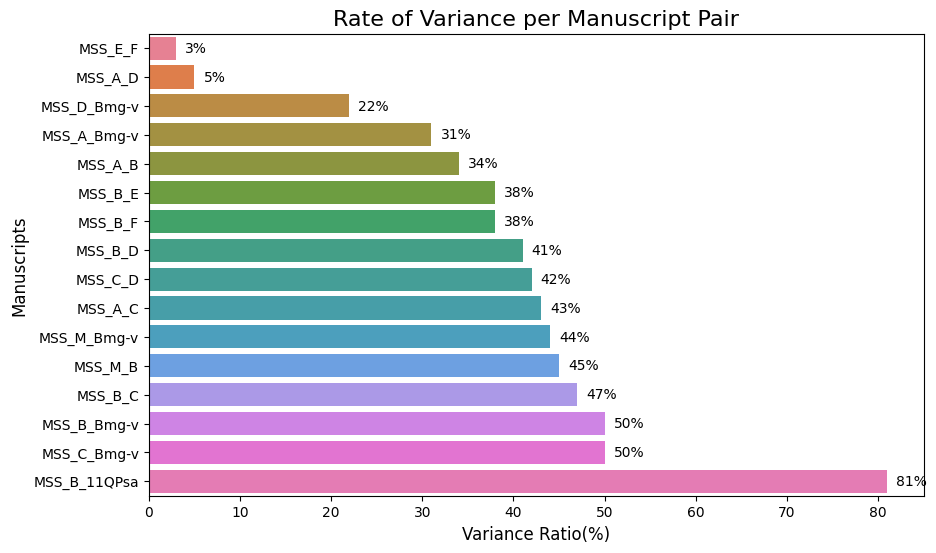

In [ ]:
"""
Ratio of variations
"""


def ratio_variance(dfs: dict[str, pd.DataFrame]) -> pd.DataFrame: 
    # Loop on each data frame in each csv
    #print(dfs.keys())
    variations = {}

    for filename, df in dfs.items():

        #Deletion of “Unclassifiable” lines
        df = df[df['Categories'] != 'Unclassifiable']
        
        variations[filename] = {}

        variants = df[df['Categories'] != 'Same'].groupby('Categories').size().sum()
        same = df[df['Categories'] == 'Same'].shape[0]
        ratio = variants * 100  / (variants+same)
        variations[filename]=[ratio]

    df = pd.DataFrame.from_dict(variations).round(0).T.sort_index(ascending=True)
    df.columns = ["ratio"]
    df = df.sort_values(by="ratio", ascending=True) #Sort by Value
    #df = df[~df.index.str.endswith('mg')] #delete all mg 
    print(df)
    # Créer le barplot horizontal
    plt.figure(figsize=(10, 6))
    #sns.set(style="whitegrid")
    palette = sns.color_palette("pastel", as_cmap=False)

    # Trace un barplot horizontal
    ax = sns.barplot(x="ratio", y=df.index, data=df, hue=df.index, dodge=False)

    # Ajouter la valeur du ratio à côté de chaque barre
    for i, (value, label) in enumerate(zip(df["ratio"], df.index)):
        ax.text(value + 1, i, f"{value:.0f}%", va='center', fontsize=10, color='black')

    # Ajouter un titre et des labels
    plt.title("Rate of Variance per Manuscript Pair without score", fontsize=16)

    # Ajouter un titre et des labels
    plt.title("Rate of Variance per Manuscript Pair", fontsize=16)
    plt.xlabel("Variance Ratio(%)", fontsize=12)
    plt.ylabel("Manuscripts", fontsize=12)

    # Afficher le graphique
    plt.show()
    #print("Index du DataFrame final :", df.index.tolist())
    return df

ratio = ratio_variance(dataframes_virtual)


# 5. Hierarchical Clustering with a variance score to 1

In [21]:
def ratio_to_matrix(ratio: pd.DataFrame) -> pd.DataFrame:

    """
    Converti un dataFrame de ratios en matrice de distance

        arg:
        ratio(pd.DataFrame) = un dataframe contenant une distance de variance du type
                                    ratio
                    MSS_E_F              3.0
                    MSS_A_D              5.0    
                    ...

        return:
        dist_matrix(pd.DataFrame) = un dataframe contenant un matrice de distance du type
                                A     B   Bmg     C     D
                        A     0.0  31.0  31.0  43.0   5.0
                        B    31.0   0.0  50.0  50.0  22.0
                        Bmg  31.0  50.0   0.0  50.0  22.0
                        C    43.0  50.0  50.0   0.0  42.0
                        D     5.0  22.0  22.0  42.0   0.0
    """

    pairs = ratio.index.str.replace("MSS_", "").str.split("_")
    #print(f"Paires: {pairs}")
    mss_set = set()
    for p in pairs:
        mss_set.update(p[:2])
    mss = sorted(mss_set)

    # Créer la matrice vide
    dist_matrix = pd.DataFrame(np.nan, index=mss, columns=mss)

    # Remplir la matrice directement depuis le DataFrame
    for idx, row in ratio.iterrows():
        m1, m2 = idx.replace("MSS_", "").split("_")[:2]
        dist_matrix.loc[m1, m2] = row["ratio"]
        dist_matrix.loc[m2, m1] = row["ratio"]
    np.fill_diagonal(dist_matrix.values, 0)

    return dist_matrix


print(ratio)
dist_matrix = ratio_to_matrix(ratio)
print(dist_matrix)


              ratio
MSS_E_F         3.0
MSS_A_D         5.0
MSS_D_Bmg-v    22.0
MSS_A_Bmg-v    31.0
MSS_A_B        34.0
MSS_B_E        38.0
MSS_B_F        38.0
MSS_B_D        41.0
MSS_C_D        42.0
MSS_A_C        43.0
MSS_M_Bmg-v    44.0
MSS_M_B        45.0
MSS_B_C        47.0
MSS_B_Bmg-v    50.0
MSS_C_Bmg-v    50.0
MSS_B_11QPsa   81.0
        11QPsa     A     B  Bmg-v     C     D     E     F     M
11QPsa     0.0   NaN  81.0    NaN   NaN   NaN   NaN   NaN   NaN
A          NaN   0.0  34.0   31.0  43.0   5.0   NaN   NaN   NaN
B         81.0  34.0   0.0   50.0  47.0  41.0  38.0  38.0  45.0
Bmg-v      NaN  31.0  50.0    0.0  50.0  22.0   NaN   NaN  44.0
C          NaN  43.0  47.0   50.0   0.0  42.0   NaN   NaN   NaN
D          NaN   5.0  41.0   22.0  42.0   0.0   NaN   NaN   NaN
E          NaN   NaN  38.0    NaN   NaN   NaN   0.0   3.0   NaN
F          NaN   NaN  38.0    NaN   NaN   NaN   3.0   0.0   NaN
M          NaN   NaN  45.0   44.0   NaN   NaN   NaN   NaN   0.0


Pour neutraliser les valeurs manquante:
https://stackoverflow.com/questions/35611465/python-scikit-learn-clustering-with-missing-data
(with implem)
https://arxiv.org/pdf/1411.7013

          A     B  Bmg-v     C     D
A       0.0  34.0   31.0  43.0   5.0
B      34.0   0.0   50.0  47.0  41.0
Bmg-v  31.0  50.0    0.0  50.0  22.0
C      43.0  47.0   50.0   0.0  42.0
D       5.0  41.0   22.0  42.0   0.0


/var/folders/4v/l62_h42s4rg1hyzc_kg9l0qm0000gn/T/ipykernel_1144/632167272.py:47: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(sub_matrix.values, method='average')


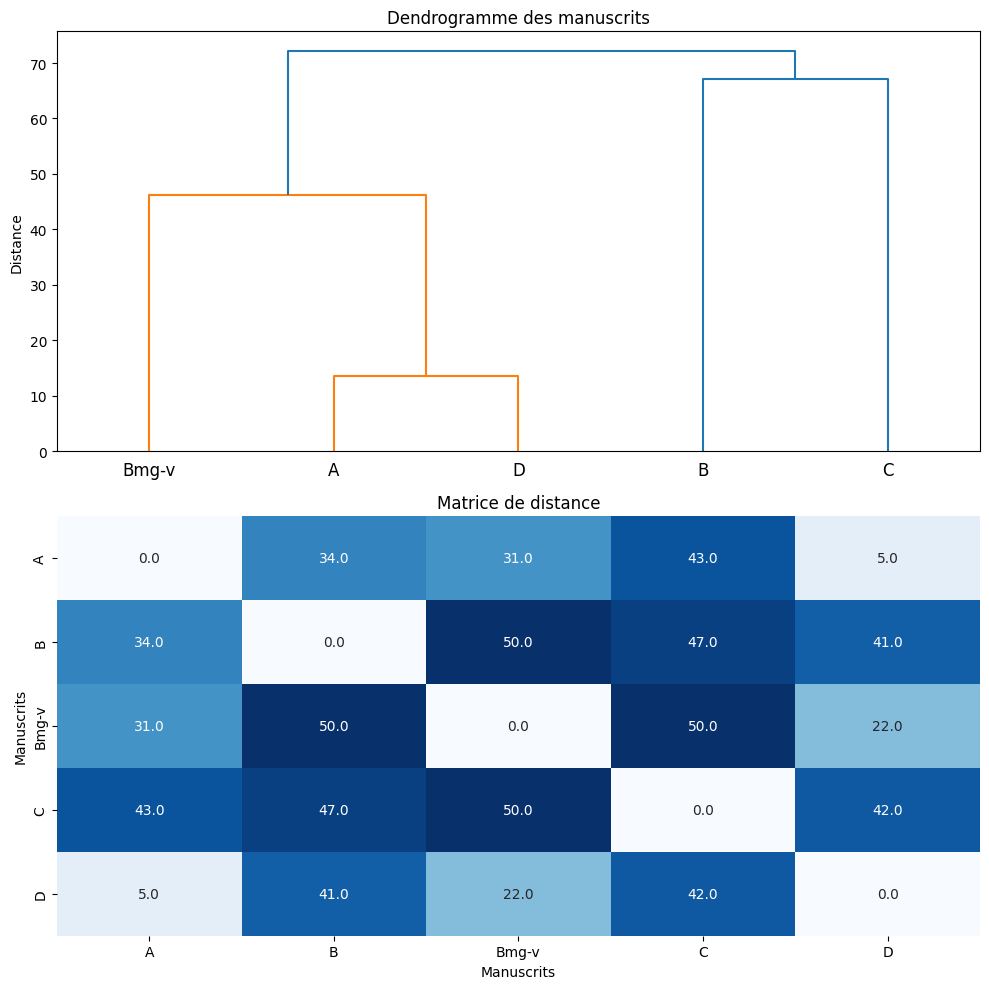

In [80]:
def get_largest_complete_submatrix(dist_matrix: pd.DataFrame) -> pd.DataFrame:
    """
    Pour chaque sous-ensemble de manuscrits, on teste si la sous-matrice est complète (pas de NaN)
    On commence par les plus grands ensembles possibles

    arg:
    dist_matrix (pd.DataFrame) = la matrice complète des distances de manuscrits avec des fragmentations
    
    return: 
    sub (pd.DataFrame) = la plus grande matrice complète possible.
    """

    from itertools import combinations
    
    mss = dist_matrix.index.tolist()
    n = len(mss)
    for size in range(n, 1, -1):
        for subset in combinations(mss, size):
            sub = dist_matrix.loc[list(subset), list(subset)]
            if not sub.isnull().values.any():
                return sub
    return None  # Si rien trouvé



def hierarchical_clustering(dist_matrix: pd.DataFrame) -> None:
    """
    Réalise une classification ascendante hierarchique sur une matrice de distance et affiche un dendograme

    arg:
    dist_matrix: pd.DataFrame = une matrice de distance...

    Retunr:
    None = le dendogramme et la matrice
    """

    sub_matrix = get_largest_complete_submatrix(dist_matrix)
    print(sub_matrix)

    # Vérification de la symétrie
    assert np.allclose(sub_matrix.values, sub_matrix.values.T), "La matrice n'est pas symétrique"

    # Dendrogramme + matrice de distance
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 2]})

    # Dendrogramme
    Z = linkage(sub_matrix.values, method='average')
    dendrogram(Z, labels=sub_matrix.index, ax=ax1)
    ax1.set_title("Dendrogramme des manuscrits")
    ax1.set_xlabel("")
    ax1.set_ylabel("Distance")

    # Matrice de distance
    sns.heatmap(sub_matrix, annot=True, cmap="Blues", fmt=".1f", ax=ax2, cbar=False)
    ax2.set_title("Matrice de distance")
    ax2.set_xlabel("Manuscrits")
    ax2.set_ylabel("Manuscrits")

    plt.tight_layout()
    plt.show()


hierarchical_clustering(dist_matrix)

## 6. Variation Rates by Categories with score

MSS_C_D nbre de variants + same : 105 - overlap : 106
MSS_A_D nbre de variants + same : 216 - overlap : 217
MSS_A_B nbre de variants + same : 444 - overlap : 448
MSS_E_F nbre de variants + same : 60 - overlap : 88
MSS_A_C nbre de variants + same : 408 - overlap : 461
MSS_B_F nbre de variants + same : 245 - overlap : 730
MSS_B_E nbre de variants + same : 71 - overlap : 97
MSS_B_D nbre de variants + same : 256 - overlap : 268
MSS_B_C nbre de variants + same : 66 - overlap : 66
MSS_B_11QPsa nbre de variants + same : 69 - overlap : 69
MSS_M_B nbre de variants + same : 664 - overlap : 681
MSS_M_Bmg-v nbre de variants + same : 655 - overlap : 715
MSS_D_Bmg-v nbre de variants + same : 254 - overlap : 268
MSS_C_Bmg-v nbre de variants + same : 66 - overlap : 66
MSS_B_Bmg-v nbre de variants + same : 66 - overlap : 66
MSS_A_Bmg-v nbre de variants + same : 443 - overlap : 448
ratio des manuscrit avec score
               ratio
MSS_C_D        28.0
MSS_A_D         1.0
MSS_A_B        26.0
MSS_E_F    

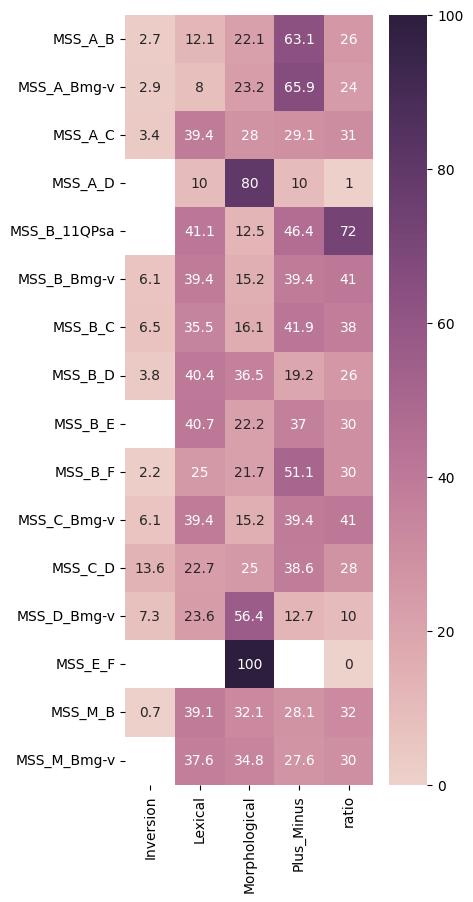

In [76]:
"""
Variation rates on categories with score by variant:
"""

def ratio_variance_scored (dfs: dict[str, pd.DataFrame]) -> pd.DataFrame:
    score = {
        "Inversion": 0.3,
        "Lexical": 1,
        "Morphological": 0.1,
        "Plus_Minus": 1
    }

    for filename, df in dfs.items():

        #Deletion of “Unclassifiable” lines
        df = df[df['Categories'] != 'Unclassifiable']

        ratio_var_scored[filename] = {}

        variants = df[df['Categories'] != 'Same'].groupby('Categories').size().to_dict() # Create a dictionary of the number of item in each category
        total_variants = df[df['Categories'] != 'Same'].groupby('Categories').size().sum()
        same = df[df['Categories'] == 'Same'].shape[0]
        overlap = df[df['Categories'] != 'Unclassifiable'].shape[0]
        print(f"{filename} nbre de variants + same : {total_variants + same} - overlap : {overlap}")
        scored_variants = {category: count * score.get(category, 1) for category, count in variants.items()}
        #print(f"{filename} with score : {scored_variants} - total variants {total_variants} - total mots {total_variants + same}")
        sum = 0
        for variant in variants:
            sum = sum + scored_variants[variant] * 100 / (total_variants + same)
            ratio_var_scored[filename][variant] = variants[variant] * 100 / total_variants
        ratio_var_scored[filename]["ratio"] = round(sum)
        #print(f"ratio variantes pondérées : {scored_variants}")
    table = pd.DataFrame.from_dict(ratio_var_scored).round(1).T.sort_index(ascending=True)
    plt.figure(figsize=(4, 10))
    sns.heatmap(table, annot=True, cmap=sns.cubehelix_palette(as_cmap=True), fmt='g')
    dist_df = pd.DataFrame.from_dict(ratio_var_scored).T[["ratio"]]
    return dist_df
    
ratio_scored = ratio_variance_scored(dataframes_virtual)
print(f"ratio des manuscrit avec score\n {ratio_scored}")

              ratio
MSS_E_F         0.0
MSS_A_D         1.0
MSS_D_Bmg-v    10.0
MSS_A_Bmg-v    24.0
MSS_A_B        26.0
MSS_B_D        26.0
MSS_C_D        28.0
MSS_B_F        30.0
MSS_B_E        30.0
MSS_M_Bmg-v    30.0
MSS_A_C        31.0
MSS_M_B        32.0
MSS_B_C        38.0
MSS_C_Bmg-v    41.0
MSS_B_Bmg-v    41.0
MSS_B_11QPsa   72.0


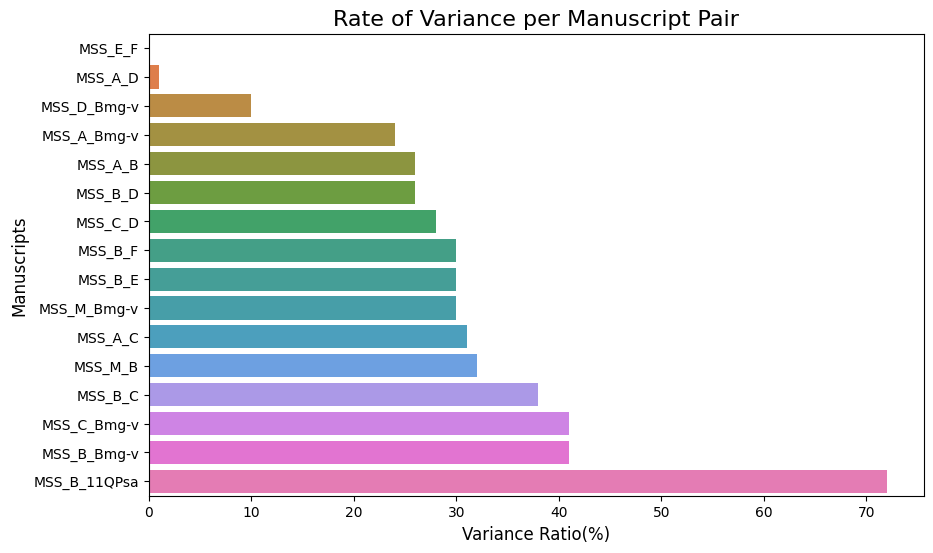

In [64]:
# Afficher Joliment les ratios

df = ratio_scored
# df.columns = ["ratio"]
df = df.sort_values(by="ratio", ascending=True) #Sort by Value
#df = df[~df.index.str.endswith('mg')] #delete all mg 
print(df)
# Créer le barplot horizontal
plt.figure(figsize=(10, 6))
#sns.set(style="whitegrid")
palette = sns.color_palette("pastel", as_cmap=False)

# Trace un barplot horizontal
sns.barplot(x="ratio", y=df.index, data=df, hue=df.index, dodge=False)

# Ajouter un titre et des labels
plt.title("Rate of Variance per Manuscript Pair", fontsize=16)
plt.xlabel("Variance Ratio(%)", fontsize=12)
plt.ylabel("Manuscripts", fontsize=12)

# Afficher le graphique
plt.show()

In [73]:
def display_matrix(matrix):
    fig, ax = plt.subplots(figsize=(10, 10), gridspec_kw={'height_ratios': [1]})
    sns.heatmap(matrix, annot=True, cmap="Blues", fmt=".1f", cbar=False)
    ax.set_title("Matrice de distance")
    ax.set_xlabel("Manuscrits")
    ax.set_ylabel("Manuscrits")
    plt.tight_layout()
    plt.show()

        11QPsa     A     B  Bmg-v     C     D     E     F     M
11QPsa     0.0   NaN  72.0    NaN   NaN   NaN   NaN   NaN   NaN
A          NaN   0.0  26.0   24.0  31.0   1.0   NaN   NaN   NaN
B         72.0  26.0   0.0   41.0  38.0  26.0  30.0  30.0  32.0
Bmg-v      NaN  24.0  41.0    0.0  41.0  10.0   NaN   NaN  30.0
C          NaN  31.0  38.0   41.0   0.0  28.0   NaN   NaN   NaN
D          NaN   1.0  26.0   10.0  28.0   0.0   NaN   NaN   NaN
E          NaN   NaN  30.0    NaN   NaN   NaN   0.0   0.0   NaN
F          NaN   NaN  30.0    NaN   NaN   NaN   0.0   0.0   NaN
M          NaN   NaN  32.0   30.0   NaN   NaN   NaN   NaN   0.0


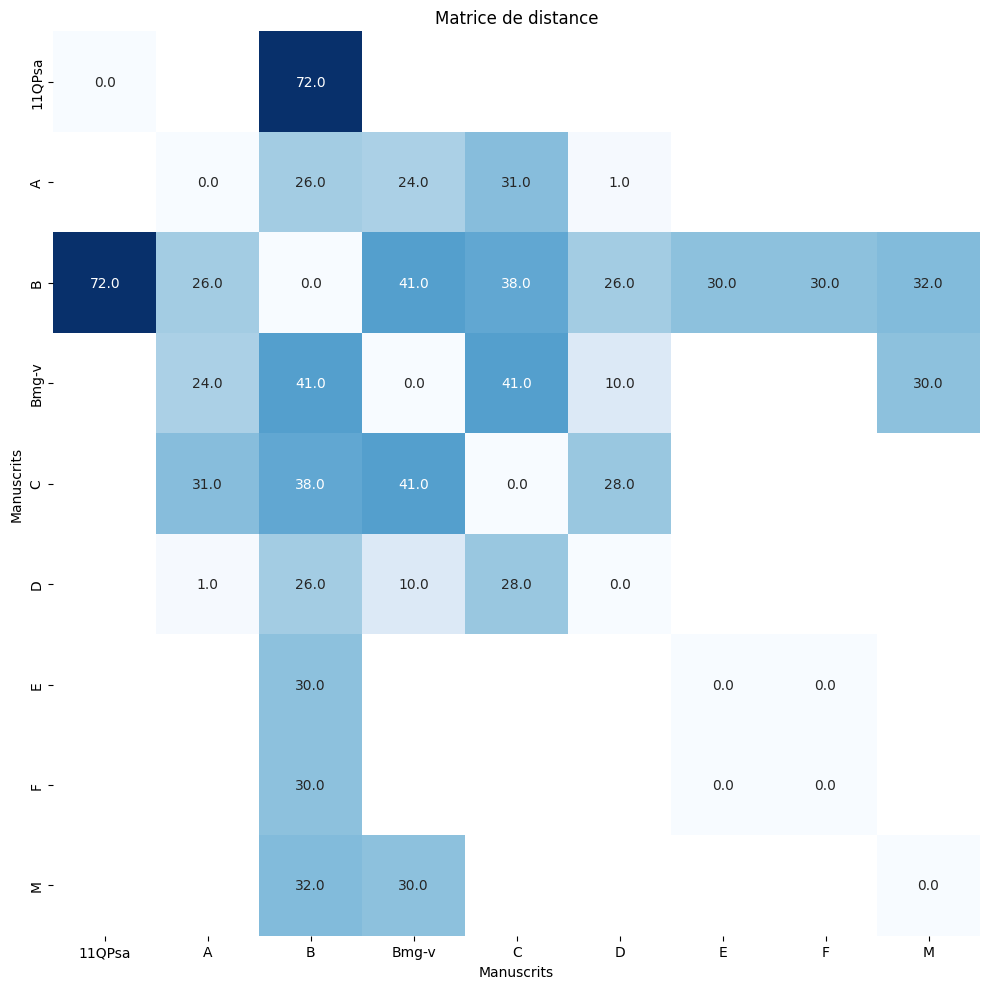

          A     B  Bmg-v     C     D
A       0.0  26.0   24.0  31.0   1.0
B      26.0   0.0   41.0  38.0  26.0
Bmg-v  24.0  41.0    0.0  41.0  10.0
C      31.0  38.0   41.0   0.0  28.0
D       1.0  26.0   10.0  28.0   0.0


/var/folders/4v/l62_h42s4rg1hyzc_kg9l0qm0000gn/T/ipykernel_1144/632167272.py:47: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(sub_matrix.values, method='average')


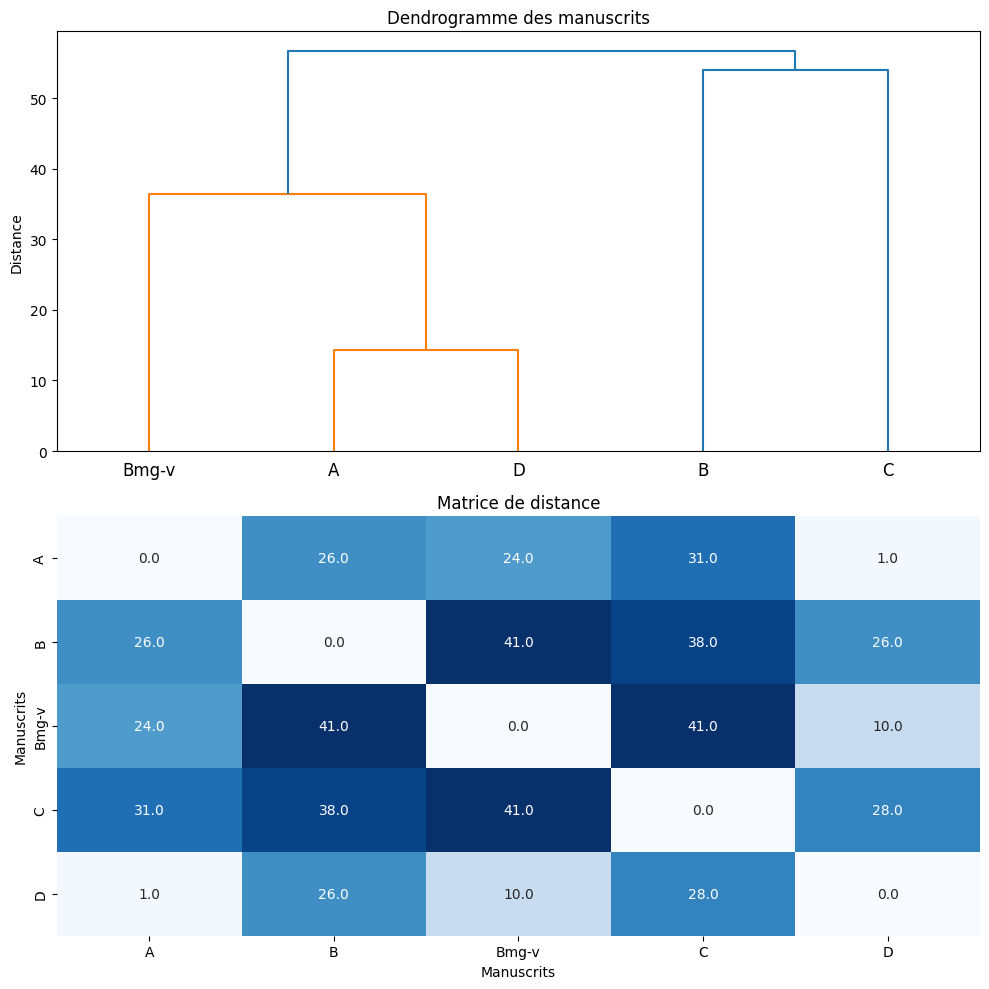

In [81]:
dist_matrix_scored = ratio_to_matrix(ratio_scored)
print(f"{dist_matrix_scored}")
display_matrix(dist_matrix_scored)
hierarchical_clustering(dist_matrix_scored)

In [25]:
overlap = df[df['Categories'] != 'Unclassifiable'].shape[0]
print(overlap, total_variants + same)


NameError: name 'df' is not defined

# Variation by categories

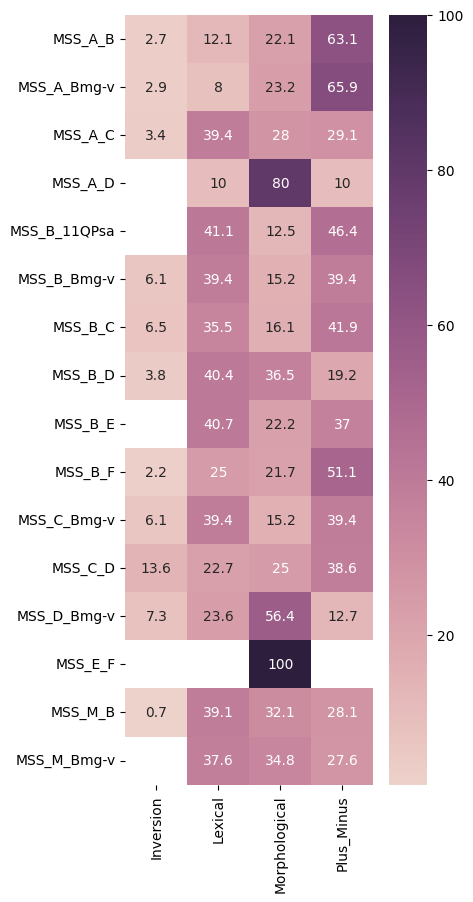

In [61]:
"""
Variation rates on categories
"""

def ratio_variance (dfs: dict[str, pd.DataFrame]) -> pd.DataFrame:
    score = {
        "Inversion": 0.2,
        "Lexical": 1,
        "Morphological": 0.1,
        "Plus_Minus": 1
    }


    for filename, df in dfs.items():

        #Deletion of “Unclassifiable” lines
        df = df[df['Categories'] != 'Unclassifiable']

        ratio_var[filename] = {}


        variants = df[df['Categories'] != 'Same'].groupby('Categories').size().to_dict() # Create a dictionary of the number of item in each category
        total_variants = df[df['Categories'] != 'Same'].groupby('Categories').size().sum()
        
        same = df[df['Categories'] == 'Same'].shape[0]
        #print(f"{filename} without score : {variants} - total variants {total_variants} - total mots {total_variants + same}")
        #scored_variants = {category: count * score.get(category, 1) for category, count in variants.items()}
        #print(f"{filename} with score : {scored_variants} - total variants {total_variants}")
        
        for variant in variants:
            ratio_var[filename][variant] = variants[variant] * 100 / total_variants

    table = pd.DataFrame.from_dict(ratio_var).round(1).T.sort_index(ascending=True)
    plt.figure(figsize=(4, 10))
    sns.heatmap(table, annot=True, cmap=sns.cubehelix_palette(as_cmap=True), fmt='g')

ratio_variance(dataframes_virtual)

#

<Axes: >

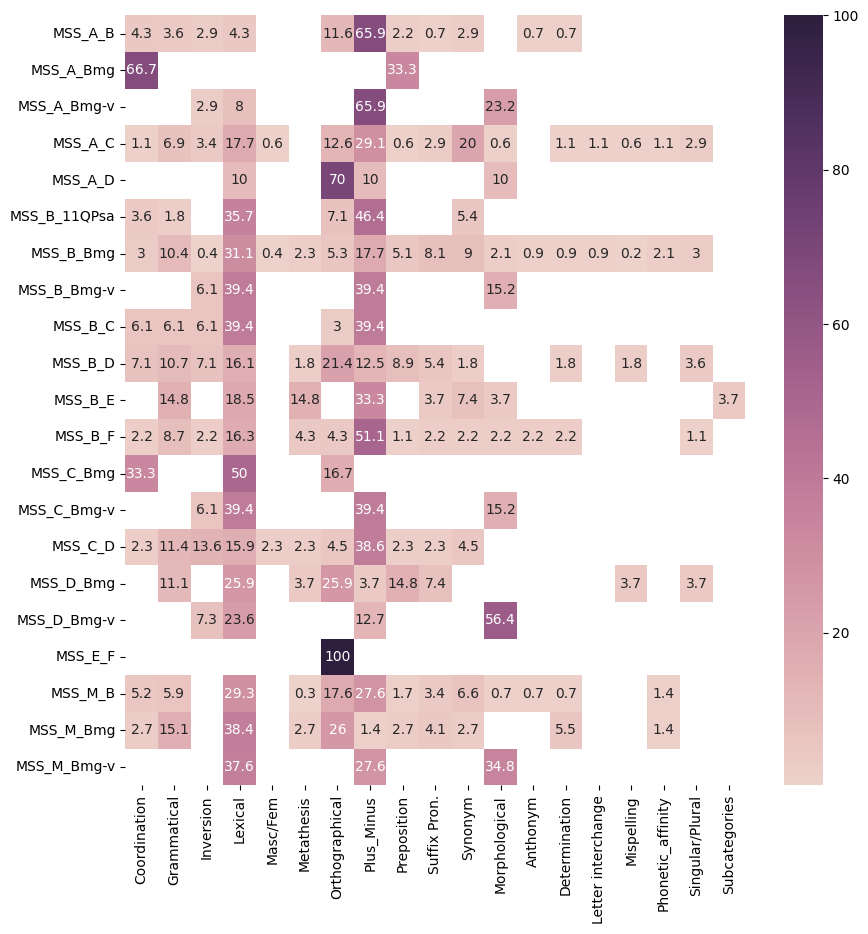

In [62]:
"""
Variation rates by subcategories
"""
for filename, df in dataframes.items():

    #Deletion of “Unclassifiable” lines
    df = df[df['Categories'] != 'Unclassifiable']

    #merge categories and subcategories
    df.loc[:, 'Subcategories_1'] = df['Subcategories_1'].fillna(df['Categories'])

    #Delete "same" lines
    df = df[df['Subcategories_1'] != 'Same']
 
    ratio_var[filename] = {}
    
    variants1 = df.groupby('Subcategories_1').size() # Create a dataframe of the number of item in each subcategories_1
    variants2 = df.groupby('Subcategories_2').size() # Create a dataframe of the number of item in each subcategories_2

# Fusionner les deux DataFrames sur la colonne 'Subcategories_1'  
    variants1 = variants1.reset_index()
    variants1.columns=["Subcategories", "value"]
    variants2 = variants2.reset_index()
    variants2.columns=["Subcategories", "value"]
    merged_variants = pd.merge(variants1, variants2, on='Subcategories', how='outer')
    merged_variants['Total'] = merged_variants['value_x'].fillna(0) + merged_variants['value_y'].fillna(0)
    variants = merged_variants.set_index('Subcategories')['Total'].to_dict()

    
    total_variants = df.groupby('Subcategories_1').size().sum()
    
    for variant in variants:
        ratio_var[filename][variant] = variants[variant] * 100 / total_variants
        

#pd.set_option('display.float_format', lambda x: 'd' % x)
table = pd.DataFrame.from_dict(ratio_var).round(1).T.sort_index(ascending=True)
plt.figure(figsize=(10, 10))
sns.heatmap(table, annot=True, cmap=sns.cubehelix_palette(as_cmap=True), fmt='g')
    

## Variation Rates by Subcategories without score

<Axes: >

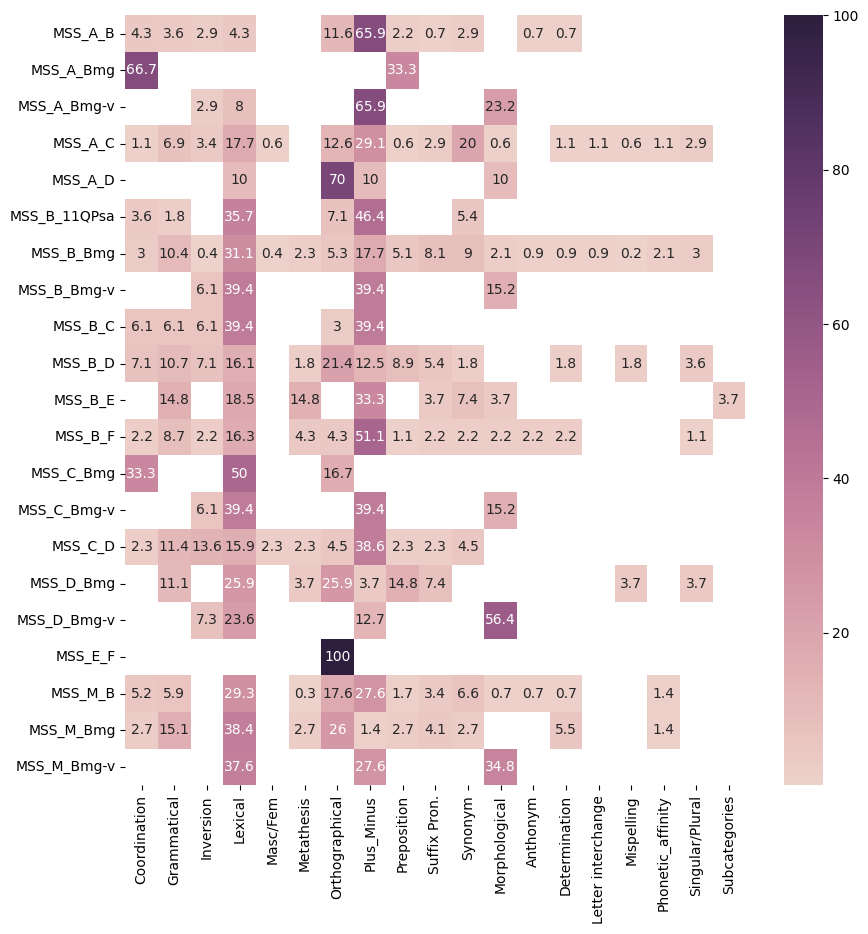

In [ ]:
"""
Variation rates by subcategories
"""
for filename, df in dataframes.items():

    #Deletion of “Unclassifiable” lines
    df = df[df['Categories'] != 'Unclassifiable']

    #merge categories and subcategories
    df.loc[:, 'Subcategories_1'] = df['Subcategories_1'].fillna(df['Categories'])

    #Delete "same" lines
    df = df[df['Subcategories_1'] != 'Same']
 
    ratio_var[filename] = {}
    
    variants1 = df.groupby('Subcategories_1').size() # Create a dataframe of the number of item in each subcategories_1
    variants2 = df.groupby('Subcategories_2').size() # Create a dataframe of the number of item in each subcategories_2

# Fusionner les deux DataFrames sur la colonne 'Subcategories_1'  
    variants1 = variants1.reset_index()
    variants1.columns=["Subcategories", "value"]
    variants2 = variants2.reset_index()
    variants2.columns=["Subcategories", "value"]
    merged_variants = pd.merge(variants1, variants2, on='Subcategories', how='outer')
    merged_variants['Total'] = merged_variants['value_x'].fillna(0) + merged_variants['value_y'].fillna(0)
    variants = merged_variants.set_index('Subcategories')['Total'].to_dict()

    
    total_variants = df.groupby('Subcategories_1').size().sum()
    
    for variant in variants:
        ratio_var[filename][variant] = variants[variant] * 100 / total_variants
        

#pd.set_option('display.float_format', lambda x: 'd' % x)
table = pd.DataFrame.from_dict(ratio_var).round(1).T.sort_index(ascending=True)
plt.figure(figsize=(10, 10))
sns.heatmap(table, annot=True, cmap=sns.cubehelix_palette(as_cmap=True), fmt='g')
    

# Collatex allignment of Sir 37:1 (MSS B, Bmg, C and D)

+-----+----+------+------+------+-------+
| B   | כל | -    | אומר | אמר  | אהבתי |
| Bmg | כל | אוהב | אומר | -    | אהבתי |
| C   | כל | אוהב | -    | יאמר | אהבתו |
| D   | כל | אוהב | אומר | -    | אהבתי |
+-----+----+------+------+------+-------+


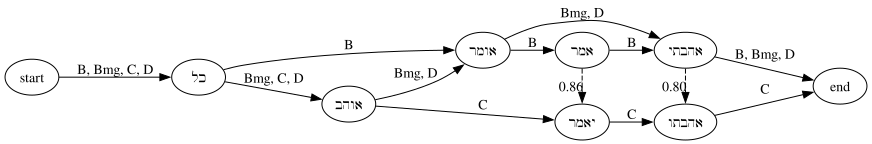

In [ ]:
from collatex import *

dataset = {
    37: {
        1: {
            "B": "כל אומר אמר אהבתי",
            "Bmg":"כל אוהב אומר אהבתי",
            "C":"כל אוהב יאמר אהבתו",
            "D":"כל אוהב אומר אהבתי"
        }
    }
}

collation = Collation()
for mss in dataset[37][1].items():
    collation.add_plain_witness(mss[0], mss[1])

alligment_table = collate(collation, near_match=True, segmentation=False)
print(alligment_table)
alligment_table_svg = collate(collation, near_match=True, segmentation=False, output = "svg_simple")

# DictaBert - Morphological Analysis of Sir 37:1

In [ ]:
from transformers import AutoModel, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('dicta-il/dictabert-morph')
model = AutoModel.from_pretrained('dicta-il/dictabert-morph', trust_remote_code=True)
model.eval()
je chfor mss in dataset[37][1].items():
    morph = model.predict([mss[1]], tokenizer)
    morph = json.dumps(morph, indent=2, ensure_ascii=False)
    print(f"Morphological Analysis of {mss[0]} : {morph}")

SyntaxError: invalid syntax (1698242065.py, line 6)